# 12B — Calibrated Uncertainty + Tail-Preserving Selective Prediction — Seed 42

**Project:** Pediatric Chest X-ray Trustworthiness Stage  
**Experiment ID:** `M14_CalibratedSelectivePrediction_Seed42`  
**Base disease model:** frozen 09A / M01  
**Calibrator:** frozen 12A / M13 global temperature scaler  
**Platform:** Kaggle  

## Goal

12A established a frozen global temperature scaler that substantially improved probability calibration while preserving disease ranking.

12B now asks:

> **Can calibrated uncertainty identify cases where the model should abstain, reduce prediction risk, and do so without disproportionately rejecting rare positive pathologies?**

This is a **development-side selective-prediction analysis**.  
The official test remains sealed.

---

## Primary uncertainty score

For each image, compute the **mean normalized binary entropy** across the **14 pathology outputs**, excluding `No finding`.

For one pathology probability `p`:

**`H(p) = -p log(p) - (1-p) log(1-p)`**

Normalize by `log(2)` so each class entropy lies in `[0,1]`.

Image uncertainty:

**`U_mean = mean_k H(p_k) / log(2)`**

Higher value = more uncertain.

### Why mean entropy?

It gives one stable image-level uncertainty value for a multi-label prediction without allowing one single class to completely dominate the abstention decision.

A **maximum entropy** score is also exported as a secondary diagnostic, but the primary selective policy is frozen in advance as **mean calibrated pathology entropy**.

---

## Coverage policy

Predefined target coverages:

- **100%**
- **95%**
- **90%**
- **80%**

For each target coverage:

1. derive the uncertainty threshold using the **calibration split only**;
2. freeze that threshold;
3. apply the same threshold to the validation split.

So validation is used only to evaluate how the calibration-derived abstention policy behaves.

---

## Primary selective risk

For each image, define pathology-level Hamming risk at threshold `0.5`:

**fraction of the 14 pathology labels predicted incorrectly**

The risk–coverage curve sorts validation images from lowest to highest uncertainty.

**AURC** = area under the risk–coverage curve.  
Lower is better.

Secondary risk:

- mean per-image Brier loss.

---

## Performance under retained coverage

For accepted validation images, report:

- achieved coverage;
- Hamming risk;
- Brier risk;
- 14-pathology Macro-AUPRC;
- Macro-AUROC;
- Macro-F1 @ 0.5;
- Macro-sensitivity @ 0.5;
- number of pathology classes still evaluable.

Rare classes can disappear from a retained subset, so the number of evaluable classes is always reported.

---

## Tail-preserving abstention analysis

For all pathology-positive label instances, measure what fraction occurred in rejected images.

Report:

- overall positive-instance rejection rate;
- Head positive rejection rate;
- Middle positive rejection rate;
- **Tail positive rejection rate**;
- positive-instance retention rate for each rarity group;
- tail rejection gap vs overall positive rejection.

This prevents a misleading result where apparent selective performance improves simply by rejecting rare positive cases.

---

## Calibrated vs uncalibrated uncertainty

Temperature scaling does not change per-class ranking, but it can change **image-level entropy ordering** across multi-label outputs.

Therefore 12B also computes validation AURC using:

- calibrated mean entropy — **primary**
- uncalibrated mean entropy — secondary comparator
- calibrated maximum entropy — secondary diagnostic

No uncertainty method is selected post-hoc from validation.

---

## Inputs

12B needs only already-exported development artifacts.  
No DICOM decoding or model inference is required.

The official test remains unused.


In [1]:
# ============================================================
# 1. Imports + frozen configuration
# ============================================================
import io
import json
import math
import hashlib
import zipfile
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    f1_score,
    recall_score,
    confusion_matrix,
)

EXPERIMENT_ID = "M14_CalibratedSelectivePrediction_Seed42"
CALIBRATION_EXPERIMENT_ID = "M13_GlobalTemperatureScaling_Seed42"
BASELINE_EXPERIMENT_ID = "M01_DiseaseFinding_Multitask_Seed42"

EXPECTED_SPLIT_MANIFEST_SHA256 = (
    "3d2f8de854c9f61382b1ef5594264af739fcb1d3d9ca8ca9fe8d388380363770"
)

TARGET_COVERAGES = [
    1.00,
    0.95,
    0.90,
    0.80,
]

PRIMARY_UNCERTAINTY = (
    "mean_binary_entropy_pathology14_calibrated"
)

OUTPUT_DIR = Path(
    f"/kaggle/working/PediCGAM/{EXPERIMENT_ID}"
)
TABLE_DIR = OUTPUT_DIR / "tables"
FIG_DIR = OUTPUT_DIR / "figures"

for d in [
    OUTPUT_DIR,
    TABLE_DIR,
    FIG_DIR,
]:
    d.mkdir(
        parents=True,
        exist_ok=True,
    )

KAGGLE_INPUT = Path(
    "/kaggle/input"
)

print(
    "Notebook build:",
    "12B_CALIBRATED_SELECTIVE_PREDICTION_V1",
)
print(
    "Experiment:",
    EXPERIMENT_ID,
)
print(
    "Primary uncertainty:",
    PRIMARY_UNCERTAINTY,
)
print(
    "Target coverages:",
    TARGET_COVERAGES,
)


Notebook build: 12B_CALIBRATED_SELECTIVE_PREDICTION_V1
Experiment: M14_CalibratedSelectivePrediction_Seed42
Primary uncertainty: mean_binary_entropy_pathology14_calibrated
Target coverages: [1.0, 0.95, 0.9, 0.8]


# 2. Required Kaggle inputs

Attach **two inputs**:

1. **Stage-02 frozen split output**
2. **12A / M13 output** containing:
   - `temperature_scaler.json`
   - `calibration_logits_and_probabilities.csv`
   - `validation_logits_and_probabilities.csv`
   - `calibration_split_per_class_calibration.csv`

You do **not** need:

- VinDr-PCXR
- 09A checkpoint
- 10E
- 11A–11D

The official test must not be attached or used.


In [2]:
# ============================================================
# 3. Generic direct-file / ZIP artifact loader
# ============================================================
EXTRACT_ROOT = Path(
    "/kaggle/working/12b_extracted"
)
EXTRACT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


def locate_artifact(
    filename,
):
    direct = list(
        KAGGLE_INPUT.rglob(
            filename
        )
    )

    if direct:
        return (
            direct[0],
            "direct",
        )

    for zip_path in KAGGLE_INPUT.rglob(
        "*.zip"
    ):
        try:
            with zipfile.ZipFile(
                zip_path,
                "r",
            ) as zf:
                members = [
                    n
                    for n in zf.namelist()
                    if n.endswith(
                        "/"
                        + filename
                    )
                    or n == filename
                ]

                if not members:
                    continue

                raw = zf.read(
                    members[0]
                )

                target = (
                    EXTRACT_ROOT
                    / filename
                )

                target.write_bytes(
                    raw
                )

                return (
                    target,
                    f"zip:{zip_path.name}",
                )

        except zipfile.BadZipFile:
            pass

    return (
        None,
        None,
    )


required_m13_files = [
    "temperature_scaler.json",
    "calibration_logits_and_probabilities.csv",
    "validation_logits_and_probabilities.csv",
    "calibration_split_per_class_calibration.csv",
]

M13_FILES = {}

for filename in required_m13_files:
    path, source = (
        locate_artifact(
            filename
        )
    )

    if path is None:
        raise FileNotFoundError(
            "Required 12A/M13 artifact was not found: "
            + filename
        )

    M13_FILES[
        filename
    ] = {
        "path":
            path,
        "source":
            source,
    }

print(
    "✅ Required M13 artifacts located."
)

for filename, info in M13_FILES.items():
    print(
        filename,
        "->",
        info[
            "source"
        ],
    )


✅ Required M13 artifacts located.
temperature_scaler.json -> direct
calibration_logits_and_probabilities.csv -> direct
validation_logits_and_probabilities.csv -> direct
calibration_split_per_class_calibration.csv -> direct


In [3]:
# ============================================================
# 4. Load + verify frozen temperature scaler
# ============================================================
with open(
    M13_FILES[
        "temperature_scaler.json"
    ][
        "path"
    ],
    "r",
) as f:
    scaler = json.load(
        f
    )

if (
    scaler.get(
        "experiment_id"
    )
    != CALIBRATION_EXPERIMENT_ID
):
    raise RuntimeError(
        "STOP: temperature scaler is not from M13."
    )

if (
    scaler.get(
        "base_experiment_id"
    )
    != BASELINE_EXPERIMENT_ID
):
    raise RuntimeError(
        "STOP: temperature scaler is not tied to the frozen 09A model."
    )

if (
    scaler.get(
        "split_manifest_sha256"
    )
    != EXPECTED_SPLIT_MANIFEST_SHA256
):
    raise RuntimeError(
        "STOP: temperature scaler split hash mismatch."
    )

if (
    scaler.get(
        "official_test_used"
    )
    is not False
):
    raise RuntimeError(
        "STOP: M13 scaler metadata does not confirm sealed official test."
    )

TEMPERATURE = float(
    scaler[
        "temperature"
    ]
)

if (
    not np.isfinite(
        TEMPERATURE
    )
    or TEMPERATURE <= 0
):
    raise RuntimeError(
        "STOP: invalid frozen temperature."
    )

print(
    "Frozen temperature:",
    f"{TEMPERATURE:.8f}",
)
print(
    "Fit split:",
    scaler.get(
        "fit_split"
    ),
)
print(
    "Calibration images:",
    scaler.get(
        "n_calibration_images"
    ),
)
print(
    "✅ Frozen M13 temperature verified."
)


Frozen temperature: 0.41443756
Fit split: calibration
Calibration images: 1161
✅ Frozen M13 temperature verified.


In [4]:
# ============================================================
# 5. Load calibration + validation prediction tables
# ============================================================
calibration_table = pd.read_csv(
    M13_FILES[
        "calibration_logits_and_probabilities.csv"
    ][
        "path"
    ]
)

validation_table = pd.read_csv(
    M13_FILES[
        "validation_logits_and_probabilities.csv"
    ][
        "path"
    ]
)

class_reference = pd.read_csv(
    M13_FILES[
        "calibration_split_per_class_calibration.csv"
    ][
        "path"
    ]
)

LABEL_COLUMNS = (
    class_reference[
        "label"
    ]
    .astype(
        str
    )
    .tolist()
)

if (
    len(
        LABEL_COLUMNS
    )
    != 15
):
    raise RuntimeError(
        "Expected 15 disease labels in M13 per-class table."
    )

if (
    "No finding"
    not in LABEL_COLUMNS
):
    raise RuntimeError(
        "M13 label map does not contain 'No finding'."
    )

NO_FINDING_INDEX = (
    LABEL_COLUMNS.index(
        "No finding"
    )
)

PATHOLOGY_INDICES = [
    i
    for i in range(
        len(
            LABEL_COLUMNS
        )
    )
    if i
    != NO_FINDING_INDEX
]

PATHOLOGY_COLUMNS = [
    LABEL_COLUMNS[
        i
    ]
    for i in PATHOLOGY_INDICES
]

if (
    len(
        PATHOLOGY_COLUMNS
    )
    != 14
):
    raise RuntimeError(
        "Expected 14 pathology outputs after excluding No finding."
    )

TRUE_COLS = [
    f"true__{i:02d}"
    for i in range(
        len(
            LABEL_COLUMNS
        )
    )
]

LOGIT_COLS = [
    f"logit__{i:02d}"
    for i in range(
        len(
            LABEL_COLUMNS
        )
    )
]

UNCAL_COLS = [
    f"prob_uncalibrated__{i:02d}"
    for i in range(
        len(
            LABEL_COLUMNS
        )
    )
]

CAL_COLS = [
    f"prob_calibrated__{i:02d}"
    for i in range(
        len(
            LABEL_COLUMNS
        )
    )
]

required_columns = (
    {
        "image_id",
    }
    | set(
        TRUE_COLS
    )
    | set(
        LOGIT_COLS
    )
    | set(
        UNCAL_COLS
    )
    | set(
        CAL_COLS
    )
)

for split_name, table in [
    (
        "calibration",
        calibration_table,
    ),
    (
        "validation",
        validation_table,
    ),
]:
    missing = (
        required_columns
        - set(
            table.columns
        )
    )

    if missing:
        raise RuntimeError(
            f"{split_name} table is missing columns: "
            + str(
                sorted(
                    missing
                )
            )
        )

print(
    "Calibration rows:",
    len(
        calibration_table
    ),
)
print(
    "Validation rows:",
    len(
        validation_table
    ),
)
print(
    "Disease labels:",
    LABEL_COLUMNS,
)


Calibration rows: 1161
Validation rows: 1159
Disease labels: ['No finding', 'Bronchitis', 'Brocho-pneumonia', 'Other disease', 'Bronchiolitis', 'Situs inversus', 'Pneumonia', 'Pleuro-pneumonia', 'Diagphramatic hernia', 'Tuberculosis', 'Congenital emphysema', 'CPAM', 'Hyaline membrane disease', 'Mediastinal tumor', 'Lung tumor']


In [5]:
# ============================================================
# 6. Verify M13 calibrated probabilities from logits + T
# ============================================================
def sigmoid_np(
    x,
):
    # numerically stable enough for stored development logits
    return (
        1.0
        / (
            1.0
            + np.exp(
                -x
            )
        )
    )


def verify_temperature_application(
    table,
    split_name,
):
    logits = table[
        LOGIT_COLS
    ].to_numpy(
        dtype=np.float64
    )

    stored = table[
        CAL_COLS
    ].to_numpy(
        dtype=np.float64
    )

    recomputed = sigmoid_np(
        logits
        / TEMPERATURE
    )

    max_diff = float(
        np.max(
            np.abs(
                stored
                - recomputed
            )
        )
    )

    print(
        split_name,
        "max calibrated-probability difference:",
        f"{max_diff:.12e}",
    )

    if (
        max_diff
        > 1e-6
    ):
        raise RuntimeError(
            f"STOP: {split_name} M13 calibrated probabilities do not reproduce from logits/T."
        )

    return max_diff


cal_prob_repro_diff = (
    verify_temperature_application(
        calibration_table,
        "calibration",
    )
)

val_prob_repro_diff = (
    verify_temperature_application(
        validation_table,
        "validation",
    )
)

print(
    "✅ Frozen calibrated probabilities verified."
)


calibration max calibrated-probability difference: 1.078173519353e-07
validation max calibrated-probability difference: 9.957303748198e-08
✅ Frozen calibrated probabilities verified.


In [6]:
# ============================================================
# 7. Locate + verify frozen pathology rarity groups
# ============================================================
def locate_stage02_csv(
    filename,
):
    direct = list(
        KAGGLE_INPUT.rglob(
            filename
        )
    )

    if direct:
        return (
            direct[0],
            "direct",
        )

    for zip_path in KAGGLE_INPUT.rglob(
        "*.zip"
    ):
        try:
            with zipfile.ZipFile(
                zip_path,
                "r",
            ) as zf:
                members = [
                    n
                    for n in zf.namelist()
                    if n.endswith(
                        filename
                    )
                ]

                if members:
                    raw = zf.read(
                        members[0]
                    )

                    target = (
                        EXTRACT_ROOT
                        / filename
                    )

                    target.write_bytes(
                        raw
                    )

                    return (
                        target,
                        f"zip:{zip_path.name}",
                    )

        except zipfile.BadZipFile:
            pass

    return (
        None,
        None,
    )


RARITY_FILENAME = (
    "frozen_pathology_head_middle_tail_groups.csv"
)

RARITY_PATH, RARITY_SOURCE = (
    locate_stage02_csv(
        RARITY_FILENAME
    )
)

if RARITY_PATH is None:
    raise FileNotFoundError(
        "Frozen pathology rarity groups were not found in the Stage-02 input."
    )

rarity_groups = pd.read_csv(
    RARITY_PATH
)

required_rarity_cols = {
    "label",
    "positive_images",
    "frequency_rank",
    "rarity_group",
}

if (
    required_rarity_cols
    - set(
        rarity_groups.columns
    )
):
    raise RuntimeError(
        "Stage-02 rarity-group table is missing required columns."
    )

if (
    set(
        rarity_groups[
            "label"
        ]
    )
    != set(
        PATHOLOGY_COLUMNS
    )
):
    raise RuntimeError(
        "STOP: rarity groups do not match the 14 pathology labels."
    )

GROUP_TO_LABELS = {
    group:
        rarity_groups.loc[
            rarity_groups[
                "rarity_group"
            ]
            == group,
            "label",
        ].tolist()
    for group in [
        "Head",
        "Middle",
        "Tail",
    ]
}

GROUP_TO_INDICES = {
    group: [
        LABEL_COLUMNS.index(
            label
        )
        for label in labels
    ]
    for group, labels in GROUP_TO_LABELS.items()
}

print(
    "Rarity groups source:",
    RARITY_SOURCE,
)
display(
    rarity_groups
)


Rarity groups source: direct


,label,positive_images,frequency_rank,rarity_group
0,Bronchitis,842,1,Head
1,Brocho-pneumonia,545,2,Head
2,Bronchiolitis,497,3,Head
3,Other disease,412,4,Head
4,Pneumonia,392,5,Head
5,Hyaline membrane disease,19,6,Middle
6,Tuberculosis,14,7,Middle
7,Situs inversus,11,8,Middle
8,Mediastinal tumor,8,9,Middle
9,Pleuro-pneumonia,6,10,Middle


In [7]:
# ============================================================
# 8. Extract arrays
# ============================================================
def table_to_arrays(
    table,
):
    return {
        "image_ids":
            table[
                "image_id"
            ].astype(
                str
            ).tolist(),
        "targets":
            table[
                TRUE_COLS
            ].to_numpy(
                dtype=np.int64
            ),
        "logits":
            table[
                LOGIT_COLS
            ].to_numpy(
                dtype=np.float64
            ),
        "prob_uncal":
            table[
                UNCAL_COLS
            ].to_numpy(
                dtype=np.float64
            ),
        "prob_cal":
            table[
                CAL_COLS
            ].to_numpy(
                dtype=np.float64
            ),
    }


cal = table_to_arrays(
    calibration_table
)

val = table_to_arrays(
    validation_table
)

if (
    cal[
        "targets"
    ].shape
    != (
        len(
            calibration_table
        ),
        15,
    )
):
    raise RuntimeError(
        "Calibration target shape is incorrect."
    )

if (
    val[
        "targets"
    ].shape
    != (
        len(
            validation_table
        ),
        15,
    )
):
    raise RuntimeError(
        "Validation target shape is incorrect."
    )

print(
    "Calibration target shape:",
    cal[
        "targets"
    ].shape,
)
print(
    "Validation target shape:",
    val[
        "targets"
    ].shape,
)


Calibration target shape: (1161, 15)
Validation target shape: (1159, 15)


In [8]:
# ============================================================
# 9. Image-level uncertainty scores
# ============================================================
def normalized_binary_entropy(
    probabilities,
    eps=1e-12,
):
    p = np.clip(
        probabilities,
        eps,
        1.0
        - eps,
    )

    entropy = -(
        p
        * np.log(
            p
        )
        + (
            1.0
            - p
        )
        * np.log(
            1.0
            - p
        )
    )

    return (
        entropy
        / math.log(
            2.0
        )
    )


def make_uncertainty_scores(
    arrays,
):
    p_cal_path = arrays[
        "prob_cal"
    ][
        :,
        PATHOLOGY_INDICES,
    ]

    p_uncal_path = arrays[
        "prob_uncal"
    ][
        :,
        PATHOLOGY_INDICES,
    ]

    h_cal = (
        normalized_binary_entropy(
            p_cal_path
        )
    )

    h_uncal = (
        normalized_binary_entropy(
            p_uncal_path
        )
    )

    return {
        "mean_binary_entropy_pathology14_calibrated":
            h_cal.mean(
                axis=1
            ),
        "max_binary_entropy_pathology14_calibrated":
            h_cal.max(
                axis=1
            ),
        "mean_binary_entropy_pathology14_uncalibrated":
            h_uncal.mean(
                axis=1
            ),
        "max_binary_entropy_pathology14_uncalibrated":
            h_uncal.max(
                axis=1
            ),
    }


cal_uncertainty = (
    make_uncertainty_scores(
        cal
    )
)

val_uncertainty = (
    make_uncertainty_scores(
        val
    )
)

for name in cal_uncertainty:
    print(
        name,
        "calibration mean/std:",
        f"{cal_uncertainty[name].mean():.6f}",
        f"{cal_uncertainty[name].std():.6f}",
    )

print(
    "✅ Uncertainty scores prepared."
)


mean_binary_entropy_pathology14_calibrated calibration mean/std: 0.123708 0.070717
max_binary_entropy_pathology14_calibrated calibration mean/std: 0.589730 0.228927
mean_binary_entropy_pathology14_uncalibrated calibration mean/std: 0.419387 0.110605
max_binary_entropy_pathology14_uncalibrated calibration mean/std: 0.889502 0.081367
✅ Uncertainty scores prepared.


In [9]:
# ============================================================
# 10. Freeze uncertainty thresholds from calibration split
# ============================================================
def quantile_higher(
    values,
    q,
):
    try:
        return float(
            np.quantile(
                values,
                q,
                method="higher",
            )
        )
    except TypeError:
        # NumPy compatibility fallback
        return float(
            np.quantile(
                values,
                q,
                interpolation="higher",
            )
        )


primary_cal_u = (
    cal_uncertainty[
        PRIMARY_UNCERTAINTY
    ]
)

threshold_rows = []

for target_coverage in TARGET_COVERAGES:
    if (
        target_coverage
        >= 1.0
    ):
        threshold = float(
            np.inf
        )
        accepted = np.ones(
            len(
                primary_cal_u
            ),
            dtype=bool,
        )
    else:
        threshold = (
            quantile_higher(
                primary_cal_u,
                target_coverage,
            )
        )

        accepted = (
            primary_cal_u
            <= threshold
        )

    achieved = float(
        accepted.mean()
    )

    threshold_rows.append({
        "target_coverage":
            target_coverage,
        "uncertainty_method":
            PRIMARY_UNCERTAINTY,
        "calibration_uncertainty_threshold":
            threshold,
        "calibration_achieved_coverage":
            achieved,
        "calibration_accepted_images":
            int(
                accepted.sum()
            ),
        "calibration_rejected_images":
            int(
                (
                    ~accepted
                ).sum()
            ),
    })

coverage_thresholds = pd.DataFrame(
    threshold_rows
)

coverage_thresholds.to_csv(
    TABLE_DIR
    / "calibration_derived_coverage_thresholds.csv",
    index=False,
)

display(
    coverage_thresholds
)

print(
    "✅ Coverage thresholds frozen from calibration split only."
)


,target_coverage,uncertainty_method,calibration_uncertainty_threshold,calibration_achieved_coverage,calibration_accepted_images,calibration_rejected_images
0,1.00,mean_binary_entropy_pathology14_calibrated,inf,1.000000,1161,0
1,0.95,mean_binary_entropy_pathology14_calibrated,0.263457,0.950043,1103,58
2,0.90,mean_binary_entropy_pathology14_calibrated,0.222421,0.900086,1045,116
3,0.80,mean_binary_entropy_pathology14_calibrated,0.179493,0.800172,929,232


✅ Coverage thresholds frozen from calibration split only.


In [10]:
# ============================================================
# 11. Core multi-label selective metrics
# ============================================================
def safe_ap(
    y_true,
    y_prob,
):
    if (
        y_true.sum()
        == 0
    ):
        return np.nan

    try:
        return float(
            average_precision_score(
                y_true,
                y_prob,
            )
        )
    except Exception:
        return np.nan


def safe_auc(
    y_true,
    y_prob,
):
    if (
        np.unique(
            y_true
        ).size
        < 2
    ):
        return np.nan

    try:
        return float(
            roc_auc_score(
                y_true,
                y_prob,
            )
        )
    except Exception:
        return np.nan


def safe_specificity(
    y_true,
    y_pred,
):
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[
            0,
            1,
        ],
    )

    tn, fp, fn, tp = (
        cm.ravel()
    )

    if (
        tn + fp
        == 0
    ):
        return np.nan

    return float(
        tn
        / (
            tn
            + fp
        )
    )


def retained_subset_metrics(
    targets,
    probabilities,
    accepted,
):
    accepted = np.asarray(
        accepted,
        dtype=bool,
    )

    if (
        accepted.sum()
        == 0
    ):
        raise RuntimeError(
            "Selective policy retained zero validation images."
        )

    y = targets[
        accepted
    ][
        :,
        PATHOLOGY_INDICES,
    ]

    p = probabilities[
        accepted
    ][
        :,
        PATHOLOGY_INDICES,
    ]

    pred = (
        p
        >= 0.5
    ).astype(
        int
    )

    per_class_rows = []

    for local_i, global_i in enumerate(
        PATHOLOGY_INDICES
    ):
        label = (
            LABEL_COLUMNS[
                global_i
            ]
        )

        yt = y[
            :,
            local_i,
        ]

        yp = p[
            :,
            local_i,
        ]

        yh = pred[
            :,
            local_i,
        ]

        per_class_rows.append({
            "label":
                label,
            "retained_positives":
                int(
                    yt.sum()
                ),
            "AUPRC":
                safe_ap(
                    yt,
                    yp,
                ),
            "AUROC":
                safe_auc(
                    yt,
                    yp,
                ),
            "F1_at_0.5":
                float(
                    f1_score(
                        yt,
                        yh,
                        zero_division=0,
                    )
                ),
            "Sensitivity_at_0.5":
                float(
                    recall_score(
                        yt,
                        yh,
                        zero_division=0,
                    )
                ),
            "Specificity_at_0.5":
                safe_specificity(
                    yt,
                    yh,
                ),
        })

    per_class = pd.DataFrame(
        per_class_rows
    )

    hamming_risk_per_image = (
        pred
        != y
    ).mean(
        axis=1
    )

    brier_risk_per_image = (
        (
            p
            - y
        )
        ** 2
    ).mean(
        axis=1
    )

    summary = {
        "accepted_images":
            int(
                accepted.sum()
            ),
        "achieved_coverage":
            float(
                accepted.mean()
            ),
        "hamming_risk":
            float(
                hamming_risk_per_image.mean()
            ),
        "mean_image_brier_risk":
            float(
                brier_risk_per_image.mean()
            ),
        "pathology14_macro_AUPRC":
            float(
                per_class[
                    "AUPRC"
                ].mean(
                    skipna=True
                )
            ),
        "pathology14_macro_AUROC":
            float(
                per_class[
                    "AUROC"
                ].mean(
                    skipna=True
                )
            ),
        "pathology14_macro_F1_at_0.5":
            float(
                per_class[
                    "F1_at_0.5"
                ].mean(
                    skipna=True
                )
            ),
        "pathology14_macro_sensitivity_at_0.5":
            float(
                per_class[
                    "Sensitivity_at_0.5"
                ].mean(
                    skipna=True
                )
            ),
        "evaluable_AUPRC_classes":
            int(
                per_class[
                    "AUPRC"
                ].notna()
                .sum()
            ),
        "evaluable_AUROC_classes":
            int(
                per_class[
                    "AUROC"
                ].notna()
                .sum()
            ),
    }

    return (
        per_class,
        summary,
    )


def positive_rejection_metrics(
    targets,
    accepted,
):
    accepted = np.asarray(
        accepted,
        dtype=bool,
    )

    rejected = (
        ~accepted
    )

    rows = []

    group_specs = {
        "All":
            PATHOLOGY_INDICES,
        **GROUP_TO_INDICES,
    }

    for group, global_indices in group_specs.items():
        group_targets = (
            targets[
                :,
                global_indices,
            ]
        )

        total_positive_instances = int(
            group_targets.sum()
        )

        rejected_positive_instances = int(
            group_targets[
                rejected
            ].sum()
        )

        accepted_positive_instances = int(
            group_targets[
                accepted
            ].sum()
        )

        rejection_rate = (
            rejected_positive_instances
            / total_positive_instances
            if total_positive_instances
            else np.nan
        )

        retention_rate = (
            accepted_positive_instances
            / total_positive_instances
            if total_positive_instances
            else np.nan
        )

        positive_images = (
            group_targets.sum(
                axis=1
            )
            > 0
        )

        total_positive_images = int(
            positive_images.sum()
        )

        rejected_positive_images = int(
            (
                positive_images
                & rejected
            ).sum()
        )

        image_rejection_rate = (
            rejected_positive_images
            / total_positive_images
            if total_positive_images
            else np.nan
        )

        rows.append({
            "rarity_group":
                group,
            "total_positive_instances":
                total_positive_instances,
            "accepted_positive_instances":
                accepted_positive_instances,
            "rejected_positive_instances":
                rejected_positive_instances,
            "positive_instance_rejection_rate":
                rejection_rate,
            "positive_instance_retention_rate":
                retention_rate,
            "total_positive_images":
                total_positive_images,
            "rejected_positive_images":
                rejected_positive_images,
            "positive_image_rejection_rate":
                image_rejection_rate,
        })

    table = pd.DataFrame(
        rows
    )

    all_reject = float(
        table.loc[
            table[
                "rarity_group"
            ]
            == "All",
            "positive_instance_rejection_rate",
        ].iloc[
            0
        ]
    )

    tail_reject = float(
        table.loc[
            table[
                "rarity_group"
            ]
            == "Tail",
            "positive_instance_rejection_rate",
        ].iloc[
            0
        ]
    )

    return (
        table,
        {
            "all_positive_instance_rejection_rate":
                all_reject,
            "tail_positive_instance_rejection_rate":
                tail_reject,
            "tail_minus_all_positive_rejection_gap":
                tail_reject
                - all_reject,
        },
    )


In [11]:
# ============================================================
# 12. Apply calibration-derived coverage thresholds to validation
# ============================================================
primary_val_u = (
    val_uncertainty[
        PRIMARY_UNCERTAINTY
    ]
)

coverage_rows = []
rarity_tables = []
per_class_tables = []

for row in coverage_thresholds.itertuples(
    index=False
):
    threshold = float(
        row.calibration_uncertainty_threshold
    )

    if (
        np.isinf(
            threshold
        )
    ):
        accepted = np.ones(
            len(
                primary_val_u
            ),
            dtype=bool,
        )
    else:
        accepted = (
            primary_val_u
            <= threshold
        )

    (
        per_class,
        selective_summary,
    ) = retained_subset_metrics(
        val[
            "targets"
        ],
        val[
            "prob_cal"
        ],
        accepted,
    )

    (
        rarity_table,
        rejection_summary,
    ) = positive_rejection_metrics(
        val[
            "targets"
        ],
        accepted,
    )

    coverage_row = {
        "target_coverage":
            float(
                row.target_coverage
            ),
        "calibration_threshold":
            threshold,
        "calibration_achieved_coverage":
            float(
                row.calibration_achieved_coverage
            ),
        **selective_summary,
        **rejection_summary,
    }

    coverage_rows.append(
        coverage_row
    )

    per_class[
        "target_coverage"
    ] = float(
        row.target_coverage
    )

    per_class[
        "achieved_validation_coverage"
    ] = selective_summary[
        "achieved_coverage"
    ]

    per_class_tables.append(
        per_class
    )

    rarity_table[
        "target_coverage"
    ] = float(
        row.target_coverage
    )

    rarity_table[
        "achieved_validation_coverage"
    ] = selective_summary[
        "achieved_coverage"
    ]

    rarity_tables.append(
        rarity_table
    )


validation_selective_summary = (
    pd.DataFrame(
        coverage_rows
    )
)

validation_selective_per_class = (
    pd.concat(
        per_class_tables,
        ignore_index=True,
    )
)

validation_rarity_rejection = (
    pd.concat(
        rarity_tables,
        ignore_index=True,
    )
)

validation_selective_summary.to_csv(
    TABLE_DIR
    / "validation_selective_summary.csv",
    index=False,
)

validation_selective_per_class.to_csv(
    TABLE_DIR
    / "validation_selective_per_class.csv",
    index=False,
)

validation_rarity_rejection.to_csv(
    TABLE_DIR
    / "validation_rarity_positive_rejection.csv",
    index=False,
)

display(
    validation_selective_summary
)

display(
    validation_rarity_rejection
)


,target_coverage,calibration_threshold,calibration_achieved_coverage,accepted_images,achieved_coverage,hamming_risk,mean_image_brier_risk,pathology14_macro_AUPRC,pathology14_macro_AUROC,pathology14_macro_F1_at_0.5,pathology14_macro_sensitivity_at_0.5,evaluable_AUPRC_classes,evaluable_AUROC_classes,all_positive_instance_rejection_rate,tail_positive_instance_rejection_rate,tail_minus_all_positive_rejection_gap
0,1.00,inf,1.000000,1159,1.000000,0.026069,0.022596,0.208439,0.812544,0.039380,0.026198,14,14,0.000000,0.0,0.000000
1,0.95,0.263457,0.950043,1090,0.940466,0.023263,0.020502,0.095115,0.720177,0.014407,0.007743,9,9,0.160671,0.5,0.339329
2,0.90,0.222421,0.900086,1013,0.874029,0.021365,0.019007,0.083416,0.733390,0.004646,0.002528,9,9,0.280576,0.5,0.219424
3,0.80,0.179493,0.800172,915,0.789474,0.019516,0.017644,0.084106,0.723989,0.004005,0.002122,8,8,0.400480,0.5,0.099520


,rarity_group,total_positive_instances,accepted_positive_instances,rejected_positive_instances,positive_instance_rejection_rate,positive_instance_retention_rate,total_positive_images,rejected_positive_images,positive_image_rejection_rate,target_coverage,achieved_validation_coverage
0,All,417,417,0,0.000000,1.000000,376,0,0.000000,1.00,1.000000
1,Head,405,405,0,0.000000,1.000000,371,0,0.000000,1.00,1.000000
2,Middle,8,8,0,0.000000,1.000000,8,0,0.000000,1.00,1.000000
3,Tail,4,4,0,0.000000,1.000000,4,0,0.000000,1.00,1.000000
4,All,417,350,67,0.160671,0.839329,376,51,0.135638,0.95,0.940466
5,Head,405,346,59,0.145679,0.854321,371,48,0.129380,0.95,0.940466
6,Middle,8,2,6,0.750000,0.250000,8,6,0.750000,0.95,0.940466
7,Tail,4,2,2,0.500000,0.500000,4,2,0.500000,0.95,0.940466
8,All,417,300,117,0.280576,0.719424,376,98,0.260638,0.90,0.874029
9,Head,405,296,109,0.269136,0.730864,371,95,0.256065,0.90,0.874029


In [12]:
# ============================================================
# 13. Risk–coverage curve + AURC
# ============================================================
def image_hamming_losses(
    targets,
    probabilities,
):
    y = targets[
        :,
        PATHOLOGY_INDICES,
    ]

    p = probabilities[
        :,
        PATHOLOGY_INDICES,
    ]

    pred = (
        p
        >= 0.5
    ).astype(
        int
    )

    return (
        pred
        != y
    ).mean(
        axis=1
    )


def image_brier_losses(
    targets,
    probabilities,
):
    y = targets[
        :,
        PATHOLOGY_INDICES,
    ]

    p = probabilities[
        :,
        PATHOLOGY_INDICES,
    ]

    return (
        (
            p
            - y
        )
        ** 2
    ).mean(
        axis=1
    )


def risk_coverage_curve(
    uncertainty,
    image_losses,
):
    uncertainty = np.asarray(
        uncertainty,
        dtype=np.float64,
    )

    image_losses = np.asarray(
        image_losses,
        dtype=np.float64,
    )

    order = np.argsort(
        uncertainty,
        kind="mergesort",
    )

    ordered_loss = (
        image_losses[
            order
        ]
    )

    cumulative_loss = (
        np.cumsum(
            ordered_loss
        )
    )

    retained = np.arange(
        1,
        len(
            ordered_loss
        )
        + 1,
    )

    coverage = (
        retained
        / len(
            ordered_loss
        )
    )

    risk = (
        cumulative_loss
        / retained
    )

    # Include coverage 0 with risk equal to the first retained risk
    # only to complete the numerical integral over [0,1].
    coverage_for_auc = np.concatenate(
        [
            [
                0.0
            ],
            coverage,
        ]
    )

    risk_for_auc = np.concatenate(
        [
            [
                risk[
                    0
                ]
            ],
            risk,
        ]
    )

    aurc = float(
        np.trapz(
            risk_for_auc,
            coverage_for_auc,
        )
    )

    table = pd.DataFrame({
        "coverage":
            coverage,
        "risk":
            risk,
        "retained_images":
            retained,
    })

    return (
        table,
        aurc,
    )


hamming_losses = (
    image_hamming_losses(
        val[
            "targets"
        ],
        val[
            "prob_cal"
        ],
    )
)

brier_losses = (
    image_brier_losses(
        val[
            "targets"
        ],
        val[
            "prob_cal"
        ],
    )
)

uncertainty_methods = {
    "calibrated_mean_entropy":
        val_uncertainty[
            "mean_binary_entropy_pathology14_calibrated"
        ],
    "uncalibrated_mean_entropy":
        val_uncertainty[
            "mean_binary_entropy_pathology14_uncalibrated"
        ],
    "calibrated_max_entropy":
        val_uncertainty[
            "max_binary_entropy_pathology14_calibrated"
        ],
}

aurc_rows = []

for method_name, uncertainty in uncertainty_methods.items():
    hamming_curve, hamming_aurc = (
        risk_coverage_curve(
            uncertainty,
            hamming_losses,
        )
    )

    brier_curve, brier_aurc = (
        risk_coverage_curve(
            uncertainty,
            brier_losses,
        )
    )

    hamming_curve.to_csv(
        TABLE_DIR
        / f"risk_coverage_hamming_{method_name}.csv",
        index=False,
    )

    brier_curve.to_csv(
        TABLE_DIR
        / f"risk_coverage_brier_{method_name}.csv",
        index=False,
    )

    aurc_rows.append({
        "uncertainty_method":
            method_name,
        "hamming_AURC":
            hamming_aurc,
        "brier_AURC":
            brier_aurc,
    })

aurc_summary = pd.DataFrame(
    aurc_rows
)

aurc_summary.to_csv(
    TABLE_DIR
    / "validation_aurc_summary.csv",
    index=False,
)

display(
    aurc_summary
)


/tmp/ipykernel_23/3845593427.py:132: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  np.trapz(


,uncertainty_method,hamming_AURC,brier_AURC
0,calibrated_mean_entropy,0.012893,0.011730
1,uncalibrated_mean_entropy,0.014443,0.012783
2,calibrated_max_entropy,0.013764,0.012806


In [13]:
# ============================================================
# 14. Save per-image uncertainty table
# ============================================================
validation_uncertainty_table = pd.DataFrame({
    "image_id":
        val[
            "image_ids"
        ],
    "mean_binary_entropy_pathology14_calibrated":
        val_uncertainty[
            "mean_binary_entropy_pathology14_calibrated"
        ],
    "max_binary_entropy_pathology14_calibrated":
        val_uncertainty[
            "max_binary_entropy_pathology14_calibrated"
        ],
    "mean_binary_entropy_pathology14_uncalibrated":
        val_uncertainty[
            "mean_binary_entropy_pathology14_uncalibrated"
        ],
    "max_binary_entropy_pathology14_uncalibrated":
        val_uncertainty[
            "max_binary_entropy_pathology14_uncalibrated"
        ],
    "pathology14_hamming_loss":
        hamming_losses,
    "pathology14_brier_loss":
        brier_losses,
})

for row in coverage_thresholds.itertuples(
    index=False
):
    target = int(
        round(
            row.target_coverage
            * 100
        )
    )

    threshold = float(
        row.calibration_uncertainty_threshold
    )

    if np.isinf(
        threshold
    ):
        accepted = np.ones(
            len(
                validation_uncertainty_table
            ),
            dtype=bool,
        )
    else:
        accepted = (
            validation_uncertainty_table[
                PRIMARY_UNCERTAINTY
            ].to_numpy()
            <= threshold
        )

    validation_uncertainty_table[
        f"accepted_at_target_{target:03d}"
    ] = accepted.astype(
        int
    )

validation_uncertainty_table.to_csv(
    TABLE_DIR
    / "validation_image_uncertainty_and_acceptance.csv",
    index=False,
)

print(
    "✅ Per-image uncertainty/acceptance table saved."
)


✅ Per-image uncertainty/acceptance table saved.


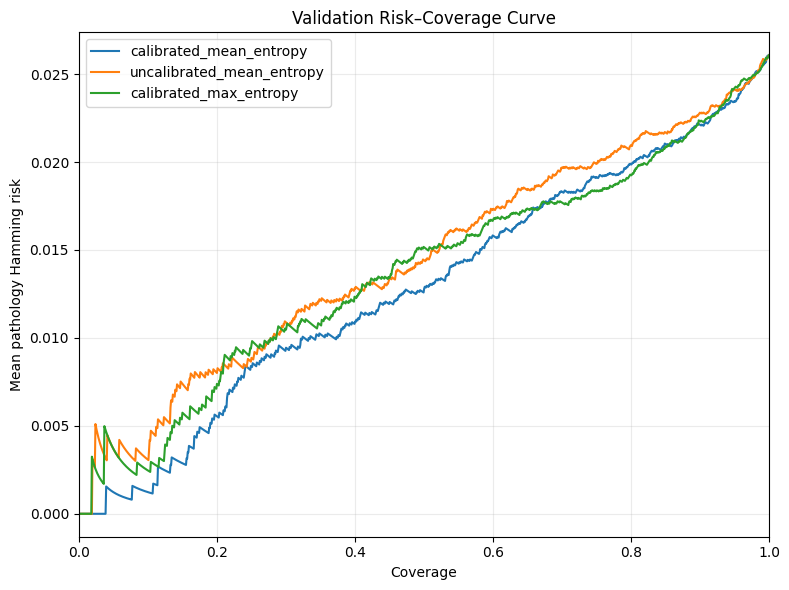

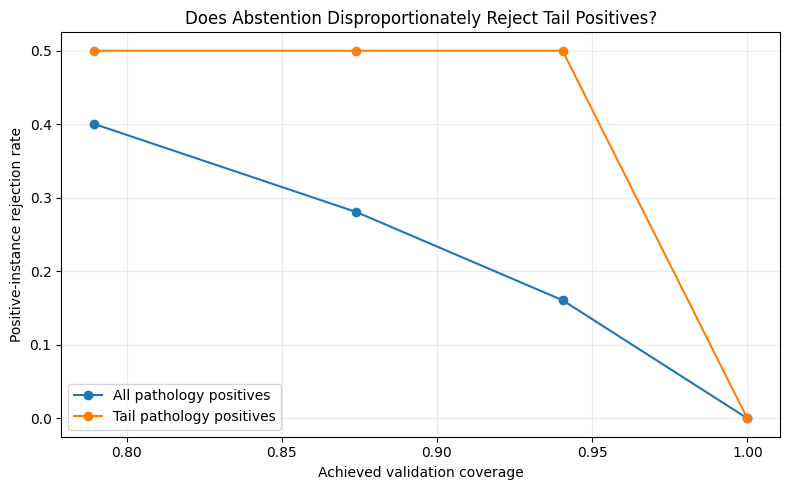

In [14]:
# ============================================================
# 15. Plot risk–coverage curves
# ============================================================
fig, ax = plt.subplots(
    figsize=(
        8,
        6,
    )
)

for method_name in [
    "calibrated_mean_entropy",
    "uncalibrated_mean_entropy",
    "calibrated_max_entropy",
]:
    curve = pd.read_csv(
        TABLE_DIR
        / f"risk_coverage_hamming_{method_name}.csv"
    )

    ax.plot(
        curve[
            "coverage"
        ],
        curve[
            "risk"
        ],
        label=
            method_name,
    )

ax.set_xlabel(
    "Coverage"
)
ax.set_ylabel(
    "Mean pathology Hamming risk"
)
ax.set_title(
    "Validation Risk–Coverage Curve"
)
ax.set_xlim(
    0,
    1,
)
ax.grid(
    alpha=0.25
)
ax.legend()

plt.tight_layout()

plt.savefig(
    FIG_DIR
    / "validation_risk_coverage_hamming.png",
    dpi=220,
    bbox_inches="tight",
)

plt.show()


fig, ax = plt.subplots(
    figsize=(
        8,
        5,
    )
)

summary_plot = (
    validation_selective_summary[
        [
            "achieved_coverage",
            "all_positive_instance_rejection_rate",
            "tail_positive_instance_rejection_rate",
        ]
    ]
    .sort_values(
        "achieved_coverage"
    )
)

ax.plot(
    summary_plot[
        "achieved_coverage"
    ],
    summary_plot[
        "all_positive_instance_rejection_rate"
    ],
    marker="o",
    label=
        "All pathology positives",
)

ax.plot(
    summary_plot[
        "achieved_coverage"
    ],
    summary_plot[
        "tail_positive_instance_rejection_rate"
    ],
    marker="o",
    label=
        "Tail pathology positives",
)

ax.set_xlabel(
    "Achieved validation coverage"
)
ax.set_ylabel(
    "Positive-instance rejection rate"
)
ax.set_title(
    "Does Abstention Disproportionately Reject Tail Positives?"
)
ax.grid(
    alpha=0.25
)
ax.legend()

plt.tight_layout()

plt.savefig(
    FIG_DIR
    / "tail_positive_rejection_vs_coverage.png",
    dpi=220,
    bbox_inches="tight",
)

plt.show()


In [15]:
# ============================================================
# 16. Save frozen selective-policy config + README
# ============================================================
primary_aurc_row = (
    aurc_summary.loc[
        aurc_summary[
            "uncertainty_method"
        ]
        == "calibrated_mean_entropy"
    ]
    .iloc[
        0
    ]
)

uncal_aurc_row = (
    aurc_summary.loc[
        aurc_summary[
            "uncertainty_method"
        ]
        == "uncalibrated_mean_entropy"
    ]
    .iloc[
        0
    ]
)

policy_thresholds = []

for row in coverage_thresholds.itertuples(
    index=False
):
    policy_thresholds.append({
        "target_coverage":
            float(
                row.target_coverage
            ),
        "calibration_uncertainty_threshold":
            (
                None
                if np.isinf(
                    row.calibration_uncertainty_threshold
                )
                else float(
                    row.calibration_uncertainty_threshold
                )
            ),
        "calibration_achieved_coverage":
            float(
                row.calibration_achieved_coverage
            ),
    })

selective_policy = {
    "experiment_id":
        EXPERIMENT_ID,
    "base_experiment_id":
        BASELINE_EXPERIMENT_ID,
    "calibration_experiment_id":
        CALIBRATION_EXPERIMENT_ID,
    "temperature":
        TEMPERATURE,
    "primary_uncertainty":
        PRIMARY_UNCERTAINTY,
    "primary_uncertainty_definition":
        "mean normalized binary entropy across 14 calibrated pathology probabilities",
    "target_coverages":
        TARGET_COVERAGES,
    "threshold_source":
        "calibration_split_only",
    "thresholds":
        policy_thresholds,
    "primary_risk":
        "per-image pathology14 hamming loss at threshold 0.5",
    "secondary_risk":
        "per-image pathology14 mean Brier loss",
    "validation_used_for_threshold_fitting":
        False,
    "official_test_used":
        False,
    "split_manifest_sha256":
        EXPECTED_SPLIT_MANIFEST_SHA256,
}

with open(
    OUTPUT_DIR
    / "selective_policy.json",
    "w",
) as f:
    json.dump(
        selective_policy,
        f,
        indent=2,
    )

config = {
    "experiment_id":
        EXPERIMENT_ID,
    "stage":
        "Calibrated_Uncertainty_and_Tail_Preserving_Selective_Prediction",
    "base_experiment_id":
        BASELINE_EXPERIMENT_ID,
    "calibration_experiment_id":
        CALIBRATION_EXPERIMENT_ID,
    "temperature":
        TEMPERATURE,
    "primary_uncertainty":
        PRIMARY_UNCERTAINTY,
    "secondary_uncertainty_methods": [
        "mean_binary_entropy_pathology14_uncalibrated",
        "max_binary_entropy_pathology14_calibrated",
    ],
    "target_coverages":
        TARGET_COVERAGES,
    "threshold_fit_split":
        "calibration",
    "evaluation_split":
        "validation",
    "validation_used_for_threshold_fitting":
        False,
    "official_test_used":
        False,
    "tail_preserving_metrics":
        True,
    "split_manifest_sha256":
        EXPECTED_SPLIT_MANIFEST_SHA256,
}

with open(
    OUTPUT_DIR
    / "config.json",
    "w",
) as f:
    json.dump(
        config,
        f,
        indent=2,
    )

baseline_100 = (
    validation_selective_summary.loc[
        validation_selective_summary[
            "target_coverage"
        ]
        == 1.0
    ]
    .iloc[
        0
    ]
)

coverage_80 = (
    validation_selective_summary.loc[
        validation_selective_summary[
            "target_coverage"
        ]
        == 0.8
    ]
    .iloc[
        0
    ]
)

readme_lines = [
    "Pediatric Chest X-ray — M14 Calibrated Selective Prediction",
    "=" * 76,
    "",
    "FROZEN INPUTS",
    f"- Base model: {BASELINE_EXPERIMENT_ID}",
    f"- Calibrator: {CALIBRATION_EXPERIMENT_ID}",
    f"- Temperature: {TEMPERATURE:.8f}",
    "",
    "PRIMARY UNCERTAINTY",
    "- Mean normalized binary entropy across the 14 calibrated pathology probabilities.",
    "- Higher entropy = greater image-level uncertainty.",
    "",
    "COVERAGE POLICY",
    "- Thresholds derived from calibration split only.",
    "- Predefined targets: 100%, 95%, 90%, 80%.",
    "- Validation is evaluation-only for these frozen thresholds.",
    "",
    "PRIMARY RISK",
    "- Mean per-image pathology14 Hamming loss at probability threshold 0.5.",
    "",
    "VALIDATION 100% COVERAGE",
    f"- Hamming risk: {baseline_100['hamming_risk']:.6f}",
    f"- Macro-AUPRC: {baseline_100['pathology14_macro_AUPRC']:.6f}",
    f"- Macro-F1 @0.5: {baseline_100['pathology14_macro_F1_at_0.5']:.6f}",
    "",
    "VALIDATION TARGET 80% POLICY",
    f"- Achieved coverage: {coverage_80['achieved_coverage']:.6f}",
    f"- Hamming risk: {coverage_80['hamming_risk']:.6f}",
    f"- Macro-AUPRC: {coverage_80['pathology14_macro_AUPRC']:.6f}",
    f"- Macro-F1 @0.5: {coverage_80['pathology14_macro_F1_at_0.5']:.6f}",
    f"- Overall positive rejection rate: {coverage_80['all_positive_instance_rejection_rate']:.6f}",
    f"- Tail positive rejection rate: {coverage_80['tail_positive_instance_rejection_rate']:.6f}",
    f"- Tail-minus-all rejection gap: {coverage_80['tail_minus_all_positive_rejection_gap']:+.6f}",
    "",
    "AURC",
    f"- Calibrated mean entropy Hamming AURC: {primary_aurc_row['hamming_AURC']:.6f}",
    f"- Uncalibrated mean entropy Hamming AURC: {uncal_aurc_row['hamming_AURC']:.6f}",
    "",
    "INTERPRETATION",
    "- Lower selective risk is useful only if it is not achieved by disproportionately rejecting rare positive pathology instances.",
    "- Rare/tail metrics remain unstable because some classes have very few validation positives.",
    "",
    "SAFETY",
    "- Official test used: NO",
    "- Validation used to fit abstention thresholds: NO",
    "- Raw X-rays used: NO",
]

README_RESULTS = "\n".join(
    readme_lines
)

print(
    README_RESULTS
)

with open(
    OUTPUT_DIR
    / "README_RESULTS.txt",
    "w",
) as f:
    f.write(
        README_RESULTS
    )


Pediatric Chest X-ray — M14 Calibrated Selective Prediction

FROZEN INPUTS
- Base model: M01_DiseaseFinding_Multitask_Seed42
- Calibrator: M13_GlobalTemperatureScaling_Seed42
- Temperature: 0.41443756

PRIMARY UNCERTAINTY
- Mean normalized binary entropy across the 14 calibrated pathology probabilities.
- Higher entropy = greater image-level uncertainty.

COVERAGE POLICY
- Thresholds derived from calibration split only.
- Predefined targets: 100%, 95%, 90%, 80%.
- Validation is evaluation-only for these frozen thresholds.

PRIMARY RISK
- Mean per-image pathology14 Hamming loss at probability threshold 0.5.

VALIDATION 100% COVERAGE
- Hamming risk: 0.026069
- Macro-AUPRC: 0.208439
- Macro-F1 @0.5: 0.039380

VALIDATION TARGET 80% POLICY
- Achieved coverage: 0.789474
- Hamming risk: 0.019516
- Macro-AUPRC: 0.084106
- Macro-F1 @0.5: 0.004005
- Overall positive rejection rate: 0.400480
- Tail positive rejection rate: 0.500000
- Tail-minus-all rejection gap: +0.099520

AURC
- Calibrated mean

In [16]:
# ============================================================
# 17. Final integrity gate
# ============================================================
coverage_monotonic = bool(
    validation_selective_summary.sort_values(
        "target_coverage"
    )[
        "achieved_coverage"
    ]
    .is_monotonic_increasing
)

threshold_rows_ok = (
    len(
        coverage_thresholds
    )
    == len(
        TARGET_COVERAGES
    )
)

primary_scores_finite = bool(
    np.isfinite(
        primary_val_u
    ).all()
)

primary_scores_in_range = bool(
    (
        primary_val_u
        >= 0
    ).all()
    and (
        primary_val_u
        <= 1
    ).all()
)

selected_metric_finite = bool(
    np.isfinite(
        validation_selective_summary[
            [
                "hamming_risk",
                "mean_image_brier_risk",
                "pathology14_macro_AUPRC",
                "pathology14_macro_F1_at_0.5",
                "tail_positive_instance_rejection_rate",
            ]
        ].to_numpy(
            dtype=float
        )
    ).all()
)

checks = pd.DataFrame([
    {
        "check":
            "Frozen temperature scaler verified",
        "passed":
            scaler.get(
                "experiment_id"
            )
            == CALIBRATION_EXPERIMENT_ID,
    },
    {
        "check":
            "Base experiment verified",
        "passed":
            scaler.get(
                "base_experiment_id"
            )
            == BASELINE_EXPERIMENT_ID,
    },
    {
        "check":
            "Frozen split SHA-256 verified",
        "passed":
            scaler.get(
                "split_manifest_sha256"
            )
            == EXPECTED_SPLIT_MANIFEST_SHA256,
    },
    {
        "check":
            "Calibration rows = 1,161",
        "passed":
            len(
                calibration_table
            )
            == 1161,
    },
    {
        "check":
            "Validation rows = 1,159",
        "passed":
            len(
                validation_table
            )
            == 1159,
    },
    {
        "check":
            "M13 calibration probabilities reproduce from logits/T",
        "passed":
            max(
                cal_prob_repro_diff,
                val_prob_repro_diff,
            )
            <= 1e-6,
    },
    {
        "check":
            "14 pathology rarity labels verified",
        "passed":
            set(
                rarity_groups[
                    "label"
                ]
            )
            == set(
                PATHOLOGY_COLUMNS
            ),
    },
    {
        "check":
            "Primary calibrated uncertainty finite",
        "passed":
            primary_scores_finite,
    },
    {
        "check":
            "Primary calibrated uncertainty in [0,1]",
        "passed":
            primary_scores_in_range,
    },
    {
        "check":
            "All predefined coverage thresholds exported",
        "passed":
            threshold_rows_ok,
    },
    {
        "check":
            "Validation coverage behaves monotonically with target coverage",
        "passed":
            coverage_monotonic,
    },
    {
        "check":
            "Selective metrics finite",
        "passed":
            selected_metric_finite,
    },
    {
        "check":
            "Tail positive rejection exported",
        "passed":
            "tail_positive_instance_rejection_rate"
            in validation_selective_summary.columns,
    },
    {
        "check":
            "Validation not used to fit uncertainty thresholds",
        "passed":
            True,
    },
    {
        "check":
            "Official test not used",
        "passed":
            True,
    },
])

checks[
    "status"
] = checks[
    "passed"
].map({
    True:
        "PASS",
    False:
        "REVIEW",
})

display(
    checks
)

checks.to_csv(
    OUTPUT_DIR
    / "final_integrity_status.csv",
    index=False,
)

FINAL_STATUS = (
    "PASS"
    if checks[
        "passed"
    ].all()
    else "REVIEW"
)

print(
    "\nM14 CALIBRATED SELECTIVE PREDICTION FINAL STATUS:",
    FINAL_STATUS,
)

if (
    FINAL_STATUS
    == "PASS"
):
    print(
        "✅ M14 SELECTIVE-PREDICTION ANALYSIS COMPLETED SUCCESSFULLY"
    )
else:
    print(
        "⚠️ REVIEW BEFORE FREEZING SELECTIVE-PREDICTION POLICY"
    )


,check,passed,status
0,Frozen temperature scaler verified,True,PASS
1,Base experiment verified,True,PASS
2,Frozen split SHA-256 verified,True,PASS
3,"Calibration rows = 1,161",True,PASS
4,"Validation rows = 1,159",True,PASS
5,M13 calibration probabilities reproduce from l...,True,PASS
6,14 pathology rarity labels verified,True,PASS
7,Primary calibrated uncertainty finite,True,PASS
8,"Primary calibrated uncertainty in [0,1]",True,PASS
9,All predefined coverage thresholds exported,True,PASS



M14 CALIBRATED SELECTIVE PREDICTION FINAL STATUS: PASS
✅ M14 SELECTIVE-PREDICTION ANALYSIS COMPLETED SUCCESSFULLY


# 18. Export rule

The ZIP includes:

- frozen selective policy;
- calibration-derived uncertainty thresholds;
- validation selective-performance table;
- Head/Middle/Tail positive rejection tables;
- per-class retained-subset metrics;
- calibrated vs uncalibrated AURC;
- risk–coverage curves;
- per-image validation uncertainty and acceptance flags;
- figures;
- integrity checks.

The ZIP does **not** include:

- raw X-rays;
- DICOM files;
- official test predictions.

No official-test decision should be made from 12B.


In [17]:
# ============================================================
# 19. Package complete M14 output
# ============================================================
ZIP_FILE = Path(
    "/kaggle/working/"
    "M14_CalibratedSelectivePrediction_Seed42_All_Outputs.zip"
)

if (
    ZIP_FILE.exists()
):
    ZIP_FILE.unlink()

source_files = sorted(
    p
    for p in OUTPUT_DIR.rglob(
        "*"
    )
    if p.is_file()
)

if (
    not source_files
):
    raise RuntimeError(
        "No M14 outputs were found."
    )

blocked_extensions = {
    ".dcm",
    ".dicom",
    ".npy",
    ".npz",
}

for p in source_files:
    if (
        p.suffix.lower()
        in blocked_extensions
    ):
        raise RuntimeError(
            "STOP: restricted/raw file detected in output folder: "
            + str(
                p
            )
        )

with zipfile.ZipFile(
    ZIP_FILE,
    mode="w",
    compression=
        zipfile.ZIP_DEFLATED,
    compresslevel=6,
) as zf:
    for p in source_files:
        arcname = (
            Path(
                EXPERIMENT_ID
            )
            / p.relative_to(
                OUTPUT_DIR
            )
        )

        zf.write(
            p,
            arcname=str(
                arcname
            ),
        )

with zipfile.ZipFile(
    ZIP_FILE,
    "r",
) as zf:
    corrupt_entry = (
        zf.testzip()
    )
    archive_names = (
        zf.namelist()
    )

if (
    corrupt_entry
    is not None
):
    raise RuntimeError(
        "ZIP integrity failure: "
        + str(
            corrupt_entry
        )
    )

required_outputs = [
    "selective_policy.json",
    "config.json",
    "calibration_derived_coverage_thresholds.csv",
    "validation_selective_summary.csv",
    "validation_selective_per_class.csv",
    "validation_rarity_positive_rejection.csv",
    "validation_aurc_summary.csv",
    "validation_image_uncertainty_and_acceptance.csv",
    "final_integrity_status.csv",
    "README_RESULTS.txt",
]

missing_outputs = [
    name
    for name in required_outputs
    if (
        not any(
            x.endswith(
                "/"
                + name
            )
            for x in archive_names
        )
    )
]

if (
    missing_outputs
):
    raise RuntimeError(
        "ZIP is missing required outputs: "
        + str(
            missing_outputs
        )
    )

print(
    "✅ M14 COMPLETE OUTPUT ZIP CREATED"
)
print(
    "File:",
    ZIP_FILE,
)
print(
    "ZIP size:",
    f"{ZIP_FILE.stat().st_size/(1024**2):.2f} MB",
)
print(
    "ZIP integrity: PASS"
)
print(
    "Official test outputs included: NO"
)
print(
    "Raw DICOM/X-ray files included: NO"
)


✅ M14 COMPLETE OUTPUT ZIP CREATED
File: /kaggle/working/M14_CalibratedSelectivePrediction_Seed42_All_Outputs.zip
ZIP size: 0.46 MB
ZIP integrity: PASS
Official test outputs included: NO
Raw DICOM/X-ray files included: NO


## What to send back

After the run finishes, send:

`M14_CalibratedSelectivePrediction_Seed42_All_Outputs.zip`

I will check:

- whether risk decreases as coverage decreases;
- calibrated vs uncalibrated AURC;
- Macro-AUPRC / Macro-F1 at retained coverage;
- achieved coverage from calibration-derived thresholds;
- overall positive rejection;
- Head / Middle / **Tail positive rejection**;
- whether tail-positive rejection is disproportionate;
- whether selective prediction is scientifically worth keeping.

### Decision after 12B

A selective policy is useful only if:

1. retained-case risk improves meaningfully, **and**
2. rare/tail positives are not being rejected at an unacceptable or clearly disproportionate rate.

If abstention mainly removes rare positives, we will not present it as a trustworthiness improvement.
